In [5]:
####################################
#ENVIRONMENT SETUP

In [6]:
#Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr

import sys; import os; import time; from datetime import timedelta
import pickle
import h5py
from tqdm import tqdm

import copy
from matplotlib.backends.backend_pdf import PdfPages

In [7]:
#MAIN DIRECTORIES
def GetDirectories():
    mainDirectory='/mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/'
    mainCodeDirectory=os.path.join(mainDirectory,"Code/CodeFiles/")
    scratchDirectory='/mnt/lustre/koa/scratch/air673/'
    codeDirectory=os.getcwd()
    return mainDirectory,mainCodeDirectory,scratchDirectory,codeDirectory

[mainDirectory,mainCodeDirectory,scratchDirectory,codeDirectory] = GetDirectories()

In [8]:
#IMPORT CLASSES
sys.path.append(os.path.join(mainCodeDirectory,"2_Variable_Calculation"))
from CLASSES_Variable_Calculation import ModelData_Class, SlurmJobArray_Class, DataManager_Class

#IMPORT FUNCTIONS
sys.path.append(os.path.join(mainCodeDirectory,"2_Variable_Calculation"))
import FUNCTIONS_Variable_Calculation
from FUNCTIONS_Variable_Calculation import *

In [9]:
#Data Loading Class
ModelData = ModelData_Class(mainDirectory, scratchDirectory, simulationNumber=1)
#data manager class
DataManager = DataManager_Class(mainDirectory, scratchDirectory, ModelData, dataType="Tracking_Algorithms", dataName="Lagrangian_UpdraftTracking",
                                dtype='float32',codeSection = "Project_Algorithms")

#data manager class (for saving data)
DataManager_TrackedProfiles = DataManager_Class(mainDirectory, scratchDirectory, ModelData, dataType="Tracked_Profiles",
                                                dataName="EntrainmentTrackback_V2", #*testing
                                                dtype='float32',codeSection = "Project_Algorithms")

=== CM1 Data Summary ===
 Simulation #:   1
 Resolution:     1km
 Time step:      5min
 Vertical levels:34
 Parcels:        1e6
 Data file:      /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Model/cm1r20.3/run/MODEL_OUTPUT/Simulation_One/cm1out_1km_5min_34nz.nc
 Parcel file:    /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Model/cm1r20.3/run/MODEL_OUTPUT/Simulation_One/cm1out_pdata_1km_5min_1e6np.nc
 Time steps:     133

=== DataManager Summary ===
 inputDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Variable_Calculation/TimeSplitModelData
 outputDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms
 inputDataDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Variable_Calculation/TimeSplitModelData/Simulation_1_1km_5min_34nz/ModelData
 inputParcelDirecto

In [10]:
#IMPORT CLASSES
sys.path.append(os.path.join(mainCodeDirectory,"3_Project_Algorithms","2_Tracking_Algorithms"))
from CLASSES_TrackingAlgorithms import TrackingAlgorithms_DataLoading_Class, Results_InputOutput_Class, TrackedParcel_Loading_Class

# IMPORT CLASSES
sys.path.append(os.path.join(mainCodeDirectory,"3_Project_Algorithms","3_Tracked_Profiles"))
from CLASSES_TrackedProfiles import TrackedProfiles_DataLoading_CLASS

In [11]:
#LOADING FUNCTIONS
import sys
path=os.path.join(mainCodeDirectory,'Functions/')
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

#####

#Import StatisticalFunctions 
import sys
dir2='/mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/'
path=dir2+'Functions/'
sys.path.append(path)

import StatisticalFunctions
from StatisticalFunctions import * # import NumericalFunctions 

In [12]:
##############################################
#JOB ARRAY

In [13]:
#JOB ARRAY SETUP
UsingJobArray=True

def GetNumJobs(res,t_res):
    num_jobs=ModelData.Ntime-1 #5min: 132; 3min: 220; 1min: 660
    return num_jobs
num_jobs = GetNumJobs(ModelData.res,ModelData.t_res)
SlurmJobArray = SlurmJobArray_Class(total_elements=ModelData.Ntime, num_jobs=num_jobs, UsingJobArray=UsingJobArray)
start_job = SlurmJobArray.start_job; end_job = SlurmJobArray.end_job

def GetNumElements():
    loop_elements = np.arange(ModelData.Ntime)[start_job:end_job]
    return loop_elements
loop_elements = GetNumElements()

Running timesteps from 0:1 



In [17]:
##############################################
#DATA LOADING FUNCTIONS

In [18]:
#Variable Data Functions

def MakeDataDictionary(variableNames,t,printstatement=False):
    timeString = ModelData.timeStrings[t]
    # print(f"Getting data from {timeString}","\n")
    
    dataDictionary = {variableName: CallLagrangianArray(ModelData, DataManager, timeString, variableName=variableName, printstatement=printstatement) 
                      for variableName in variableNames}      
    return dataDictionary
    
def GetSpatialData(t):    
    variableNames = ['Z','Y','X']
    dataDictionary = MakeDataDictionary(variableNames,t)
    [Z,Y,X] = (dataDictionary[k] for k in variableNames)
    return Z,Y,X
def GetZ(t):    
    variableNames = ['Z']
    dataDictionary = MakeDataDictionary(variableNames,t)
    [Z] = (dataDictionary[k] for k in variableNames)
    return [Z]
    
def GetLangrangianBinaryArray(t):
    Processed_String='PROCESSED_'
    variableNames=[f'{Processed_String}A_g',f'{Processed_String}A_c']
    dataDictionary = MakeDataDictionary(variableNames,t)
    [A_g,A_c] = (dataDictionary[k] for k in variableNames)
    return A_g,A_c

In [41]:
#Tracked Data Functions
def GetTrackedArrays():
    [trackedArrays,_]\
    = TrackedParcel_Loading_Class.LoadingSubsetParcelData(ModelData,DataManager,              
                                                          Results_InputOutput_Class,verbose=False)

    trackedArrays.pop('turbulentCL'); trackedArrays.pop('Thermal')

    parcelDepth=GetParcelDepth()
    for key1,inner1 in trackedArrays.items():
        if "SHALLOW" not in parcelDepth:
            inner1.pop('SHALLOW')
        if "DEEP" not in parcelDepth:
            inner1.pop('DEEP')
    return trackedArrays

def GetParcelDepth():
    return 'ALL'

In [20]:
########################################
#MAIN CALCULATION FUNCTIONS

In [21]:
#Entrainment Mask Calculation Functions
def CalculateEntrainment(t, Z,Y,X,Z_Prior,Y_Prior,X_Prior, A1,A2, A1_Prior,A2_Prior,
                         isRemoveCondOrEvapEvents=True): 
    """
    Function to compute Lagrangian entrainment mask
    """
    
    #Calculation for Entrainment and Detrainment
    DMatrix_Entrainment = SubtractA(A2,A2_Prior)

    # Update D for entrainment/detrainment
    DMatrix_Entrainment[DMatrix_Entrainment < 0] = 0

    # Remove in-situ condensation/evaporation events
    if isRemoveCondOrEvapEvents:
        DMatrix_Entrainment=RemoveCondOrEvapEvents(DMatrix_Entrainment,Z,Y,X,Z_Prior,Y_Prior,X_Prior)

    if t==0:
        entrainmentMask = np.zeros_like(A2, dtype=bool)
        return [entrainmentMask]
    else:
        entrainmentMask = DMatrix_Entrainment.astype(bool)
        return [entrainmentMask]

def SubtractA(A,A_Prior):
    D = np.zeros_like(A,dtype=np.int8)
    D = A*1 - A_Prior*1
    return D

def RemoveCondOrEvapEvents(array,
                           Z,Y,X,Z_Prior,Y_Prior,X_Prior):
    ParcelMoved = (Z != Z_Prior) | (Y != Y_Prior) | (X != X_Prior)
    array[~ParcelMoved]=0
    return array

def CalculateBothEntrainments(t, Z,Y,X,Z_Prior,Y_Prior,X_Prior,
                              A_g,A_c,A_g_Prior,A_c_Prior):
    [entrainmentMask_g] = CalculateEntrainment(t, Z,Y,X,Z_Prior,Y_Prior,X_Prior,
                                             A1=A_c,A2=A_g,A1_Prior=A_c_Prior,A2_Prior=A_g_Prior)
    
    [entrainmentMask_c] = CalculateEntrainment(t, Z,Y,X,Z_Prior,Y_Prior,X_Prior, 
                                             A1=A_g,A2=A_c,A1_Prior=A_g_Prior,A2_Prior=A_c_Prior)
    return [entrainmentMask_g,entrainmentMask_c]

In [66]:
#Histogram Settings Functions

#Initialize Histogram Functions
def InitializeHistogramsDictionary(trackedArrays, varNames, trackTimes, property_bins, property_bins_Perturbation):
    """
    Initialize All Histograms in a Dictionary
    """
    histogramsDictionary = {}
    numTLevels = len(trackTimes)
    numZLevels = len(ModelData.zh[ModelData.zh < 6])
    parcelDepth = GetParcelDepth()

    for category in ['Any']+list(trackedArrays.keys()):
        histogramsDictionary[category] = {}
        histogramsDictionary[category][parcelDepth] = {}
        for updraftType in ["g","c"]:
            histogramsDictionary[category][parcelDepth][updraftType] = {}
            for varName in varNames + [a+'_prime' for a in varNames]:
                if varName.endswith('_prime'):
                    numVarBins = len(property_bins_Perturbation[varName]) - 1
                else:
                    numVarBins = len(property_bins[varName]) - 1
                histogramsDictionary[category][parcelDepth][updraftType][varName] = MakeHistogram3D(
                    numTLevels, numZLevels, numVarBins
                )
    return histogramsDictionary

def InitializeJointHistogramsDictionary(trackedArrays, varNames, trackTimes, z_bins, property_bins_Perturbation):
    """
    Initialize All Joint (QV_prime vs. other _prime variable) Histograms in a Dictionary.
    """
    histogramsDictionary = {}
    numTLevels = len(trackTimes)
    numZLevels = len(z_bins) - 1
    parcelDepth = GetParcelDepth()
    varPairs = GetJointVarPairs(varNames)

    for category in ['Any']+list(trackedArrays.keys()):
        histogramsDictionary[category] = {}
        histogramsDictionary[category][parcelDepth] = {}
        for updraftType in ["g","c"]:
            histogramsDictionary[category][parcelDepth][updraftType] = {}
            for varName_1, varName_2 in varPairs:
                pairKey = f"{varName_1}--{varName_2}"
                numVarBins_1 = len(property_bins_Perturbation[varName_1]) - 1
                numVarBins_2 = len(property_bins_Perturbation[varName_2]) - 1
                histogramsDictionary[category][parcelDepth][updraftType][pairKey] = np.zeros(
                    (numTLevels, numZLevels, numVarBins_1, numVarBins_2)
                )
    return histogramsDictionary
    
def MakeHistogram3D(numTLevels, numZLevels, numVarBins):
    """
    Create an empty 3D histogram array with axes (time, z, variable property).
    """
    histogram3D = np.zeros((numTLevels, numZLevels, numVarBins))
    return histogram3D

#Histogram Binning Functions

def BinHistogram(histogramsDictionary, varName, relative_time,
            entrainedVariableData, entrainedVariableData_t, entrainedZ,
            parcelType, parcelDepth, updraftType,
            time_bins, z_bins,
            property_bins, property_bins_Perturbation):
    """
    Bins already-masked entrained parcel data (raw and perturbation) into a 3D (time, z, property) histogram.
    """
    #Non-Perturbation Values
    countsRaw, _ = np.histogramdd(
        sample=np.column_stack([
            np.full_like(entrainedVariableData, relative_time),
            entrainedZ,
            entrainedVariableData]),
        bins=[time_bins, z_bins, property_bins[varName]] #(time, z, property)
    )
    histogramsDictionary[parcelType][parcelDepth][updraftType][varName] += countsRaw

    #Perturbation Values (value at t_back minus value at t, for the same parcels)
    primeVarName = varName+'_prime'
    entrainedVariableData_prime = entrainedVariableData - entrainedVariableData_t
    countsPrime, _ = np.histogramdd(
        sample=np.column_stack([
            np.full_like(entrainedVariableData_prime, relative_time),
            entrainedZ,
            entrainedVariableData_prime
        ]),
        bins=[time_bins, z_bins, property_bins_Perturbation[primeVarName]] #(time, z, property)
    )
    histogramsDictionary[parcelType][parcelDepth][updraftType][primeVarName] += countsPrime
    return histogramsDictionary

def BinJointHistogram(histogramsDictionary, varName_1, varName_2, relative_time,
                       entrainedVariableData_1, entrainedVariableData_1_t,
                       entrainedVariableData_2, entrainedVariableData_2_t,
                       entrainedZ,
                       parcelType, parcelDepth, updraftType,
                       time_bins, z_bins,
                       property_bins_Perturbation):
    primeVarName_1 = varName_1+'_prime'
    primeVarName_2 = varName_2+'_prime'

    entrainedVariableData_1_prime = entrainedVariableData_1 - entrainedVariableData_1_t
    entrainedVariableData_2_prime = entrainedVariableData_2 - entrainedVariableData_2_t

    pairKey = f"{primeVarName_1}--{primeVarName_2}"
    counts, _ = np.histogramdd(
        sample=np.column_stack([
            np.full_like(entrainedVariableData_1_prime, relative_time),
            entrainedZ,
            entrainedVariableData_1_prime,
            entrainedVariableData_2_prime]),
        bins=[time_bins, z_bins, property_bins_Perturbation[primeVarName_1], property_bins_Perturbation[primeVarName_2]] #(time, z, property_1, property_2)
    )
    histogramsDictionary[parcelType][parcelDepth][updraftType][pairKey] += counts
    return histogramsDictionary

In [67]:
#Histogram Variable Bin Settings
def GetVarNames():
    varNames = ["W"]
    varNames += ["QV","RH_vapor","QCQI"]
    varNames += ["T",'THETA_v']
    return varNames
    
def GetJointVarPairs(varNames):
    """
    Pairs QV against every other variable, plus the same pairing for the _prime versions.
    """
    varPairs = [("QV_prime", varName+"_prime") for varName in varNames if varName != "QV"]
    # varPairs += [("QV", varName) for varName in varNames if varName != "QV"]
    return varPairs
    
def GetPropertyBins(n_bins=500):
    """
    Bins for histogram of raw variable values (no baseline subtraction).
    #CheckRanges: these are rough atmospheric defaults - confirm against your simulation's actual value ranges
    """
    property_bins_Dictionary = {
        "QV":       np.linspace(10/1e3, 20/1e3, n_bins+1),   # kg/kg
        "RH_vapor": np.linspace(30/1e2, 100/1e2, n_bins+1),        # %
        "QCQI":     np.linspace(0, 3/1e3, n_bins+1),      # kg/kg
        "W":        np.linspace(-10, 10, n_bins+1),       # m/s
        "T":        np.linspace(280, 315, n_bins+1),      # K
        "THETA_v":  np.linspace(300, 320, n_bins+1),      # K
    }
    return property_bins_Dictionary

def GetPropertyBins_Perturbations(n_bins=500):
    """
    Bins for histogram of perturbations
    defined as value minus value at time of entrainment
    """
    property_bins_Dictionary = {
        "QV":    MakeSignedLogBins(None, 5e-5, 5/1e3, n_bins),
        "RH_vapor": MakeSignedLogBins(None, 0.01/1e2, 2/1e2, n_bins), 
        "QCQI":  MakeSignedLogBins(None, 1e-8, 2/1e3, n_bins),
        "W":     MakeSignedLogBins(None, 0.02, 15, n_bins),
        "T":     MakeSignedLogBins(-10, 0.01, 30, n_bins),
        "THETA_v":    MakeSignedLogBins(None, 0.1, 10, n_bins),
    }
    
    for varName in list(property_bins_Dictionary.keys()):
        property_bins_Dictionary[varName+"_prime"] = property_bins_Dictionary[varName]
    return property_bins_Dictionary
    
def MakeSignedLogBins(minValue=-1, centerValue=0.01, maxValue=1, nBins=500):
    """
    Create symmetric signed-logarithmic bins including zero.
    minValue: negative endpoint (e.g. -20) — most extreme negative bin edge.
    centerValue: small positive magnitude closest to zero on both sides (e.g. 0.01).
    maxValue: positive endpoint (e.g. 30) — most extreme positive bin edge.
    """
    if nBins % 2 != 0:
        raise ValueError("nBins must be even for signed-log bins")
    if minValue is not None and minValue >= 0:
        raise ValueError("minValue must be negative")
    halfBins = nBins // 2
    
    # positive side (log-spaced, excludes zero): centerValue -> maxValue
    pos = np.logspace(
        np.log10(centerValue),
        np.log10(maxValue),
        halfBins
    )
    # negative side mirror
    if minValue is None:
        neg = -pos[::-1]
    else:
        # negative side (log-spaced, excludes zero): centerValue -> abs(minValue)
        neg = -np.logspace(
            np.log10(centerValue),
            np.log10(-minValue),
            halfBins
        )[::-1]
        
    # form bins with 0 in the center
    bins = np.concatenate([neg, [0.0], pos])
    return bins

In [68]:
#Preconditioning Binning Functions
def MaskData(variableData,entrainmentMask,Z,Y,X,
             trackedArrays,t_back,parcelType='Any'):

    if parcelType == 'Any':
        return entrainmentMask

    #else
    trackedParcelList = trackedArrays[parcelType][GetParcelDepth()] 
    pIndex = trackedParcelList[:,0]
    t1 = trackedParcelList[:,1]; t2 = trackedParcelList[:,2]

    #Selects Tracked Parcels where t_back is in their Ascent Time Interval
    withinTimeInterval = np.zeros(ModelData.Np, dtype=bool)
    withinTimeInterval[pIndex] = (t_back >= t1) & (t_back <= t2)
    trackedPs = np.where(withinTimeInterval)[0]

    #Selects parcesl that share a gridbox
    #flattening Z,Y,X into one grid-cell ID per parcel (vectorized) #Morton-style linear index
    #cellID = (Z * ModelData.Nyh + Y) * ModelData.Nxh + X
    cellID = np.ravel_multi_index((Z, Y, X), (ModelData.Nzh, ModelData.Nyh, ModelData.Nxh)) #same

    trackedCellIDs = cellID[trackedPs]
    sharesGridbox = np.isin(cellID, trackedCellIDs)
    sharesGridbox[trackedPs] = False
    
    entrainedMask = entrainmentMask & sharesGridbox
    return entrainedMask

def GetCoordinateBins():

    #Time Bins
    timesteps_per_min = 1/(ModelData.time[1].item()/1e9/60)
    timesteps_per_hour = int(60*timesteps_per_min)
    # time_bins = np.arange(0,(0-timesteps_per_hour)-1,-1)[::-1]
    time_bins = np.arange(0.5, -timesteps_per_hour-1.5, -1)[::-1]

    numLevelsBelow6km = np.sum(ModelData.zh < 6)
    z_bins = np.arange(-0.5, numLevelsBelow6km + 0.5, 1)

    return (time_bins,timesteps_per_hour,z_bins)

In [91]:
#Calculation Functions
loop_elements=[110] #*testing
def RunCode():
    """
    Coordinates 60 minute trackback binning of entrained parcel data
    for for all parcelTypes (i.e. 'CL','nonCL','SBF','ColdPool')
    """
    
    #Getting VariableNames and Bins
    varNames=GetVarNames()
    property_bins=GetPropertyBins() 
    property_bins_Perturbation=GetPropertyBins_Perturbations() 
    [time_bins,timesteps_per_hour,
     z_bins]=GetCoordinateBins()
    
    #Get Tracked Parcel Data
    trackedArrays=GetTrackedArrays()
    
    #Running Through Each Time
    for t in tqdm(loop_elements, desc="Processing"):
        if ModelData.time_hrs[t]<10: #LT
            print(f"skipping time {t} at {ModelData.time_hrs[t]} is before 10 LT")
            continue
        
        #getting variable data
        [Z,Y,X] = GetSpatialData(t)
        [Z_Prior,Y_Prior,X_Prior] = GetSpatialData(t-1)
        [A_g,A_c] = GetLangrangianBinaryArray(t)
        [A_g_Prior,A_c_Prior] = GetLangrangianBinaryArray(t-1)
        [entrainmentMask_g,entrainmentMask_c]\
        =CalculateBothEntrainments(t,
                                   Z,Y,X,Z_Prior,Y_Prior,X_Prior,
                                   A_g,A_c,A_g_Prior,A_c_Prior)

        trackTimes = np.arange(t,(t-timesteps_per_hour*1)-1,-1)

        histogramsDictionary\
        = InitializeHistogramsDictionary(trackedArrays, varNames, 
                                         trackTimes, 
                                         property_bins,
                                         property_bins_Perturbation)
        jointHistogramsDictionary\
        = InitializeJointHistogramsDictionary(trackedArrays, varNames,   
                                              trackTimes, z_bins,        
                                              property_bins_Perturbation) 

        TrackBackData(t,varNames,histogramsDictionary,jointHistogramsDictionary,
                      trackedArrays,entrainmentMask_g,entrainmentMask_c,
                      trackTimes,time_bins,z_bins,
                      property_bins,property_bins_Perturbation)

        #Save Data #...
    return (histogramsDictionary,jointHistogramsDictionary)

def TrackBackData(t,varNames,histogramsDictionary,jointHistogramsDictionary, 
                  trackedArrays,entrainmentMask_g,entrainmentMask_c,
                  trackTimes,time_bins,z_bins,
                  property_bins,property_bins_Perturbation):
    
    #backwards loop here
    varDictionary_t = MakeDataDictionary(varNames, t)
    for count, t_back in enumerate(tqdm(trackTimes,desc="\t\tTracking back parcels",leave=False)):
        relative_time = t_back - t
        
        varDictionary = MakeDataDictionary(varNames, t_back) #get all variables at specified time
        [Z,Y,X] = GetSpatialData(t_back)
        
        BinVariablesToHistogram(varDictionary,varDictionary_t,trackedArrays,
                                t_back,Z,Y,X,relative_time,
                                histogramsDictionary,
                                entrainmentMask_g,entrainmentMask_c,
                                time_bins,z_bins,
                                property_bins,property_bins_Perturbation)
        
        # BinVariablesToJointHistogram(varDictionary,varDictionary_t,trackedArrays,varNames,
        #                              t_back,Z,Y,X,relative_time,
        #                              jointHistogramsDictionary,
        #                              entrainmentMask_g,entrainmentMask_c,
        #                              time_bins,z_bins,
        #                              property_bins_Perturbation)

def BinVariablesToHistogram(varDictionary, varDictionary_t, trackedArrays,
                            t_back, Z, Y, X, relative_time,
                            histogramsDictionary,
                            entrainmentMask_g, entrainmentMask_c,
                            time_bins, z_bins,
                            property_bins, property_bins_Perturbation):
    parcelDepth = GetParcelDepth()
    for varName in varDictionary.keys():
        variableData = varDictionary[varName]
        variableData_t = varDictionary_t[varName]
        for parcelType in ['Any']+list(trackedArrays.keys()):
            mask_g = MaskData(variableData, entrainmentMask_g, Z,Y,X,
                              trackedArrays, t_back, parcelType) #subset only the entrained data
            mask_c = MaskData(variableData, entrainmentMask_c, Z,Y,X,
                              trackedArrays, t_back, parcelType) #subset only the entrained data
            for updraftType, mask in [("g", mask_g), ("c", mask_c)]:
                BinHistogram(histogramsDictionary,varName,relative_time,
                        variableData[mask], variableData_t[mask], Z[mask],
                        parcelType, parcelDepth, updraftType,
                        time_bins, z_bins,
                        property_bins, property_bins_Perturbation) #bin the data into histogramsDictionary
    return histogramsDictionary

def BinVariablesToJointHistogram(varDictionary, varDictionary_t, trackedArrays, varNames,
                                 t_back, Z, Y, X, relative_time,
                                 jointHistogramsDictionary,
                                 entrainmentMask_g, entrainmentMask_c,
                                 time_bins, z_bins,
                                 property_bins_Perturbation):
    parcelDepth = GetParcelDepth()
    for varName_1, varName_2 in GetJointVarPairs(varNames):
        baseVarName_1 = varName_1.replace('_prime',''); baseVarName_2 = varName_2.replace('_prime','')
        variableData_1 = varDictionary[baseVarName_1]; variableData_1_t = varDictionary_t[baseVarName_1]
        variableData_2 = varDictionary[baseVarName_2]; variableData_2_t = varDictionary_t[baseVarName_2]
        for parcelType in ['Any']+list(trackedArrays.keys()):
            mask_g = MaskData(variableData_1, entrainmentMask_g, Z,Y,X,
                              trackedArrays, t_back, parcelType)
            mask_c = MaskData(variableData_1, entrainmentMask_c, Z,Y,X,
                              trackedArrays, t_back, parcelType)
            for updraftType, mask in [("g", mask_g), ("c", mask_c)]:
                BinJointHistogram(jointHistogramsDictionary, baseVarName_1, baseVarName_2, relative_time,
                        variableData_1[mask], variableData_1_t[mask],
                        variableData_2[mask], variableData_2_t[mask],
                        Z[mask],
                        parcelType, parcelDepth, updraftType,
                        time_bins, z_bins,
                        property_bins_Perturbation)
    return jointHistogramsDictionary

In [92]:
(histogramsDictionary,jointHistogramsDictionary) = RunCode()

Processing: 100%|██████████| 1/1 [00:26<00:00, 26.94s/it]               


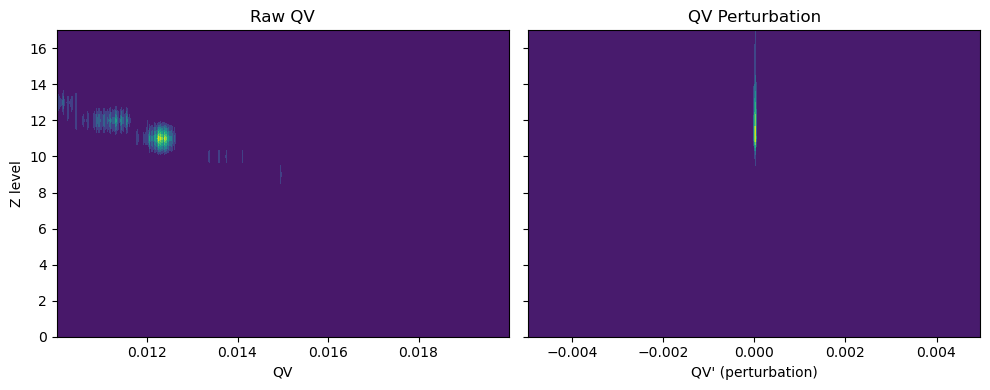

In [94]:
#test plot

time=1

property_bins=GetPropertyBins() 
property_bins_Perturbation=GetPropertyBins_Perturbations() 

qv_bins = property_bins['QV']
qv_centers = 0.5*(qv_bins[:-1] + qv_bins[1:])
qv_prime_bins = property_bins_Perturbation['QV_prime']
qv_prime_centers = 0.5*(qv_prime_bins[:-1] + qv_prime_bins[1:])

[time_bins,timesteps_per_hour,z_bins]=GetCoordinateBins()
z_centers = 0.5*(z_bins[:-1] + z_bins[1:])

a_raw = histogramsDictionary['Any']['ALL']['c']['QV'][-time]
a_prime = histogramsDictionary['Any']['ALL']['c']['QV_prime'][-time]

fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)

axes[0].contourf(qv_centers, z_centers, a_raw)
axes[0].set_xlabel("QV")
axes[0].set_ylabel("Z level")
axes[0].set_title("Raw QV")

axes[1].contourf(qv_prime_centers, z_centers, a_prime)
axes[1].set_xlabel("QV' (perturbation)")
axes[1].set_title("QV Perturbation")

plt.tight_layout()

In [10]:
#Functions For Making Property Histograms
def AccumulatePropertyHistogram_Perturbations(histogramsDictionary,
                                key1,key2,varName,
                                array,Z,
                                collapsed_g,collapsed_c,
                                relative_time,
                                property_bins_Dictionary,
                                time_bins,zBins_km_g,zBins_km_c,
                                baselineValues=None):
    for mode, collapsed, zBins_km in (
        ("g", collapsed_g, zBins_km_g),
        ("c", collapsed_c, zBins_km_c),
    ):
        if (collapsed is None): continue

        #GETTING PROPERTY HISTOGRAMS
        ##########
        # property values at this time for these entrained parcels
        properties = array[collapsed]
        if baselineValues is not None:
            properties -= baselineValues[varName][collapsed] #Subtracting Perturbations Here
        zVals_km = ModelData.zh[Z[collapsed]]
        
        # time arrays for histogram2d
        times = np.full(properties.shape, relative_time)
        # property bins for each varName
        property_bins = property_bins_Dictionary[varName]
    
        # ==========================================================
        # Make histograms
        # ==========================================================
        for z1, z2 in zBins_km:
            zMask = (zVals_km >= z1) & (zVals_km < z2)
            if not np.any(zMask):
                continue
            property_hist2d_Z, _, _ = np.histogram2d(
                times[zMask],
                properties[zMask],
                bins=(time_bins, property_bins)
            )
    
            zKey = f"{z1}_{z2}km_hist2d"
            histogramsDictionary[key1][key2][varName][mode][zKey] += property_hist2d_Z

def AccumulatePropertyHistogram_Perturbations_ZSubsetting(histogramsDictionary, #*ZSubsetting
                                key1,key2,varName,
                                array,Z,
                                collapsed_g,collapsed_c,
                                relative_time,
                                property_bins_Dictionary,
                                z_bins,timesteps_per_min,tBins_mins_g,tBins_mins_c, #*ZSubsetting
                                baselineValues):
    for mode, collapsed, tBins_mins in ( #*ZSubsetting
        ("g", collapsed_g, tBins_mins_g), #*ZSubsetting
        ("c", collapsed_c, tBins_mins_c), #*ZSubsetting
    ):
        if (collapsed is None): continue
            

        #GETTING PROPERTY HISTOGRAMS
        ##########
        # property values at this time for these entrained parcels
        properties = array[collapsed] - baselineValues[varName][collapsed] #*PERTURBATION
        zVals_km = Z[collapsed] #*ZSubsetting
        
        # property bins for each varName
        property_bins = property_bins_Dictionary[varName]
    
        # ==========================================================
        # Make histograms
        # ==========================================================
        for t1,t2 in tBins_mins: #*ZSubsetting
            if CheckRelativeTimeMatch([(t1,t2)],relative_time,
                                      timesteps_per_min) is False: #*ZSubsetting
                continue
            
            property_hist2d_T, _, _ = np.histogram2d( #*ZSubsetting
                zVals_km, #*ZSubsetting
                properties, #*ZSubsetting
                bins=(z_bins, property_bins)
            )
    
            tKey = f"{t1}_{t2}mins_hist2d" #*ZSubsetting
            histogramsDictionary[key1][key2][varName][mode][tKey] += property_hist2d_T #*ZSubsetting

def AccumulatePropertyHistogram_Perturbations_ZSubsetting_HeightAverage(histogramsDictionary, #*ZSubsetting
                                                          ZhistogramsDictionary, #*HeightAverage
                                                          key1,key2,varName_1,varName_2, #*HeightAverage
                                                          array_1,array_2,Z, #*HeightAverage
                                                          collapsed_g,collapsed_c,
                                                          relative_time,property_bins_Dictionary,
                                                          z_bins,timesteps_per_min,tBins_mins_g,tBins_mins_c, #*ZSubsetting
                                                          baselineValues):
    for mode, collapsed, tBins_mins in ( #*ZSubsetting
        ("g", collapsed_g, tBins_mins_g), #*ZSubsetting
        ("c", collapsed_c, tBins_mins_c), #*ZSubsetting
    ):
        if (collapsed is None): continue
            

        #GETTING PROPERTY HISTOGRAMS
        ##########
        # property values at this time for these entrained parcels
        properties_1 = array_1[collapsed] - baselineValues[varName_1][collapsed] #*PERTURBATION #*HeightAverage
        properties_2 = array_2[collapsed] - baselineValues[varName_2][collapsed] #*PERTURBATION #*HeightAverage
        zVals_km = ModelData.zh[Z[collapsed]] #*ZSubsetting
        
        # property bins for each varName
        property_1_bins = property_bins_Dictionary[varName_1] #*HeightAverage
        property_2_bins = property_bins_Dictionary[varName_2] #*HeightAverage
    
        # ==========================================================
        # Make histograms
        # ==========================================================
        for t1,t2 in tBins_mins: #*ZSubsetting
            if CheckRelativeTimeMatch([(t1,t2)],relative_time,
                                      timesteps_per_min) is False: #*ZSubsetting
                continue

            property_hist2d_T, _, _ = np.histogram2d( #*ZSubsetting
                properties_1, #*ZSubsetting
                properties_2, #*ZSubsetting
                bins=(property_1_bins, property_2_bins),
                
            )
            Z_hist2d_T, _, _ = np.histogram2d( #*ZSubsetting
                properties_1, #*ZSubsetting
                properties_2, #*ZSubsetting
                bins=(property_1_bins, property_2_bins),
                weights=zVals_km
            )
    
            tKey = f"{t1}_{t2}mins_hist2d" #*ZSubsetting
            histogramsDictionary[key1][key2][f"{varName_1}--{varName_2}"][mode][tKey] += property_hist2d_T #*ZSubsetting
            ZhistogramsDictionary[key1][key2][f"{varName_1}--{varName_2}"][mode][tKey] += Z_hist2d_T #*ZSubsetting

def CheckRelativeTimeMatch(tBins_mins,relative_time,
                           timesteps_per_min): #*ZSubsetting
    if not [(t1, t2) for t1, t2 in tBins_mins 
        if relative_time in np.arange(-int(timesteps_per_min*t1)-1, -int(timesteps_per_min*t2)-1, -1)]: 
        return False
    else:
        return True

In [11]:
def MakeTrackedProfiles(trackedArrays,histogramsDictionary,
                                      property_bins_Dictionary,varNames,
                                      Z,Y,X,t, A_g,A_c,A_g_Prior,A_c_Prior,
                                      time_bins,timesteps_per_hour,zBins_km_g,zBins_km_c,
                                      printstatement=True,calculatePerturbations=True):
    """
    Update profileArraysDictionary with variable data for parcels active at time t.
    Accumulates sums and counts in both profile_array and profile_array_squares.
    """
    
    baselineValues = MakeDataDictionary(varNames, t) if calculatePerturbations else None #Calculating Baseline for Perturbations
    #CALCULATING
    for key1, subdict in trackedArrays.items():         # e.g. 'CL', 'SBF'
        print("\t",f'working on {key1}')
        for key2, trackedArray in subdict.items():           # e.g. 'ALL', 'DEEP'
            print("\t\t",f'working on {key2}')
    
            #Part 1: getting parcels in trackedArray to run through
            if printstatement: print(f"Part 1: getting parcels in trackedArray to run through")
                
            _, selectedPs, leftRightIndexes = GetParcelNumbers(trackedArray, t) #get parcels that are counted at time t
            if printstatement: print(f"\tRunning for {len(selectedPs)} Parcels")
            
            #getting Z,Y,X data
            zLevels = Z[selectedPs]; yLevels = Y[selectedPs]; xLevels = X[selectedPs]

            #Part 2: find which other parcels exist in each grid box
            if printstatement: print(f"Part 2: find which other parcels exist in each grid box")
                
            # Step a: compute spatial matches once
            if printstatement: print("\tStep a: compute spatial matches once") #SLOW POINT HERE
            gridboxMatches = GetGridBoxMatches_V2(Z,Y,X, zLevels,yLevels,xLevels)
            if gridboxMatches is None:
                continue

            #Part 3: find which of those parcels were entrained into a general/cloudy updraft
            if printstatement: print(f"Part 3: find which of those parcels were entrained into a general/cloudy updraft")
            
            # Step a: compute entrainment masks
            if printstatement: print("\tStep a: compute entrainment masks")
            mask_g,mask_c = GetEntrainmentMask(A_g,A_g_Prior,
                                               A_c,A_c_Prior,
                                               selectedPs)

            # Step b: apply masks to find all parcels
            if printstatement: print("\tStep b: apply masks to find all parcels") #SLOW POINT HERE
            collapsed_g = GetWhereOtherEntrainedParcels_V2(mask_g,gridboxMatches)
            collapsed_c = GetWhereOtherEntrainedParcels_V2(mask_c,gridboxMatches)
            if (collapsed_g is None) and (collapsed_c is None): continue

            # Step c: track parcels back (last 30 minutes) and read properties
            if printstatement: print("\tStep c: track parcels back (last 60 minutes) and read properties")

            trackTimes = np.arange(t,(t-timesteps_per_hour)-1,-1)
            for count, t_back in enumerate(tqdm(trackTimes,desc="\t\tTracking back parcels",leave=False)):
                relative_time = t_back - t

                VARs = MakeDataDictionary(varNames, t_back)   
                for varName, array in VARs.items():
                    #GETTING PROPERTY HISTOGRAMS
                    AccumulatePropertyHistogram_Perturbations(histogramsDictionary,
                                                key1,key2,varName,
                                                array,Z,
                                                collapsed_g,collapsed_c,
                                                relative_time,
                                                property_bins_Dictionary,
                                                time_bins,zBins_km_g,zBins_km_c,
                                                baselineValues)
    return histogramsDictionary

def MakeTrackedProfiles_Perturbations_ZSubsetting(trackedArrays,histogramsDictionary,
                                    property_bins_Dictionary,varNames,
                                    Z,Y,X,t,A_g,A_c,A_g_Prior,A_c_Prior,
                                    timesteps_per_hour,timesteps_per_min,
                                    tBins_mins_g,tBins_mins_c,z_bins, #*ZSubsetting
                                    printstatement=True):
    """
    Update profileArraysDictionary with variable data for parcels active at time t.
    Accumulates sums and counts in both profile_array and profile_array_squares.
    """
    
    baselineValues = MakeDataDictionary(varNames, t) #*PERTURBATION
    #CALCULATING
    for key1, subdict in trackedArrays.items():         # e.g. 'CL', 'SBF'
        print("\t",f'working on {key1}')
        for key2, trackedArray in subdict.items():           # e.g. 'ALL', 'DEEP'
            print("\t\t",f'working on {key2}')
    
            #Part 1: getting parcels in trackedArray to run through
            if printstatement: print(f"Part 1: getting parcels in trackedArray to run through")
                
            _, selectedPs, leftRightIndexes = GetParcelNumbers(trackedArray, t) #get parcels that are counted at time t
            if printstatement: print(f"\tRunning for {len(selectedPs)} Parcels")
            
            #getting Z,Y,X data
            zLevels = Z[selectedPs]; yLevels = Y[selectedPs]; xLevels = X[selectedPs]

            #Part 2: find which other parcels exist in each grid box
            if printstatement: print(f"Part 2: find which other parcels exist in each grid box")
                
            # Step a: compute spatial matches once
            if printstatement: print("\tStep a: compute spatial matches once") #SLOW POINT HERE
            gridboxMatches = GetGridBoxMatches_V2(Z,Y,X, zLevels,yLevels,xLevels)
            if gridboxMatches is None:
                continue

            #Part 3: find which of those parcels were entrained into a general/cloudy updraft
            if printstatement: print(f"Part 3: find which of those parcels were entrained into a general/cloudy updraft")
            
            # Step a: compute entrainment masks
            if printstatement: print("\tStep a: compute entrainment masks")
            mask_g,mask_c = GetEntrainmentMask(A_g,A_g_Prior,
                                               A_c,A_c_Prior,
                                               selectedPs)

            # Step b: apply masks to find all parcels
            if printstatement: print("\tStep b: apply masks to find all parcels") #SLOW POINT HERE
            collapsed_g = GetWhereOtherEntrainedParcels_V2(mask_g,gridboxMatches)
            collapsed_c = GetWhereOtherEntrainedParcels_V2(mask_c,gridboxMatches)
            if (collapsed_g is None) and (collapsed_c is None): continue

            # Step c: track parcels back (last 30 minutes) and read properties
            if printstatement: print("\tStep c: track parcels back (last 60 minutes) and read properties")
            
            trackTimes = np.arange(t,(t-timesteps_per_hour)-1,-1)
            for count, t_back in enumerate(tqdm(trackTimes,desc="\t\tTracking back parcels",leave=False)):
                relative_time = t_back - t
                if CheckRelativeTimeMatch(tBins_mins_g,relative_time,timesteps_per_min) is False and CheckRelativeTimeMatch(tBins_mins_c,relative_time,timesteps_per_min) is False: #*ZSubsetting
                    continue

                VARs = MakeDataDictionary(varNames, t_back)   
                for varName, array in VARs.items():
                    #GETTING PROPERTY HISTOGRAMS
                    AccumulatePropertyHistogram_Perturbations_ZSubsetting(histogramsDictionary,
                                                            key1,key2,varName,
                                                            array,Z,
                                                            collapsed_g,collapsed_c,
                                                            relative_time,property_bins_Dictionary,
                                                            z_bins,
                                                            timesteps_per_min,
                                                            tBins_mins_g,tBins_mins_c, #*ZSubsetting
                                                            baselineValues) #*PERTURBATION
    return histogramsDictionary

def MakeTrackedProfiles_Perturbations_ZSubsetting_HeightAverage(trackedArrays,histogramsDictionary,
                                                  ZhistogramsDictionary, #*HeightAverage
                                                  property_bins_Dictionary,varNames,
                                                  Z,Y,X,t, A_g,A_c,A_g_Prior,A_c_Prior,
                                                  timesteps_per_hour,timesteps_per_min,
                                                  z_bins,tBins_mins_g,tBins_mins_c, #*ZSubsetting
                                                  varPairs, #*HeightAverage
                                                  printstatement=True):
    """
    Update profileArraysDictionary with variable data for parcels active at time t.
    Accumulates sums and counts in both profile_array and profile_array_squares.
    """
    
    baselineValues = MakeDataDictionary(varNames, t) #*PERTURBATION
    #CALCULATING
    for key1, subdict in trackedArrays.items():         # e.g. 'CL', 'SBF'
        print("\t",f'working on {key1}')
        for key2, trackedArray in subdict.items():           # e.g. 'ALL', 'DEEP'
            print("\t\t",f'working on {key2}')
    
            #Part 1: getting parcels in trackedArray to run through
            if printstatement: print(f"Part 1: getting parcels in trackedArray to run through")
                
            _, selectedPs, leftRightIndexes = GetParcelNumbers(trackedArray, t) #get parcels that are counted at time t
            if printstatement: print(f"\tRunning for {len(selectedPs)} Parcels")
            
            #getting Z,Y,X data
            zLevels = Z[selectedPs]; yLevels = Y[selectedPs]; xLevels = X[selectedPs]

            #Part 2: find which other parcels exist in each grid box
            if printstatement: print(f"Part 2: find which other parcels exist in each grid box")
                
            # Step a: compute spatial matches once
            if printstatement: print("\tStep a: compute spatial matches once") #SLOW POINT HERE
            gridboxMatches = GetGridBoxMatches_V2(Z,Y,X, zLevels,yLevels,xLevels)
            if gridboxMatches is None:
                continue

            #Part 3: find which of those parcels were entrained into a general/cloudy updraft
            if printstatement: print(f"Part 3: find which of those parcels were entrained into a general/cloudy updraft")
            
            # Step a: compute entrainment masks
            if printstatement: print("\tStep a: compute entrainment masks")
            mask_g,mask_c = GetEntrainmentMask(A_g,A_g_Prior,
                                               A_c,A_c_Prior,
                                               selectedPs)

            # Step b: apply masks to find all parcels
            if printstatement: print("\tStep b: apply masks to find all parcels") #SLOW POINT HERE
            collapsed_g = GetWhereOtherEntrainedParcels_V2(mask_g,gridboxMatches)
            collapsed_c = GetWhereOtherEntrainedParcels_V2(mask_c,gridboxMatches)
            if (collapsed_g is None) and (collapsed_c is None): continue

            # Step c: track parcels back (last 30 minutes) and read properties
            if printstatement: print("\tStep c: track parcels back (last 60 minutes) and read properties")
            
            trackTimes = np.arange(t,(t-timesteps_per_hour)-1,-1)
            for count, t_back in enumerate(tqdm(trackTimes,desc="\t\tTracking back parcels",leave=False)):
                relative_time = t_back - t
                if CheckRelativeTimeMatch(tBins_mins_g,relative_time,
                                          timesteps_per_min) is False\
                and CheckRelativeTimeMatch(tBins_mins_c,relative_time,
                                           timesteps_per_min) is False: #*ZSubsetting
                    continue

                VARs = MakeDataDictionary(varNames, t_back)   
                for varName_1, varName_2 in varPairs: #*HeightAverage
                    array_1 = VARs[varName_1]; array_2 = VARs[varName_2] #*HeightAverage
                    #GETTING PROPERTY HISTOGRAMS
                    AccumulatePropertyHistogram_Perturbations_ZSubsetting_HeightAverage(histogramsDictionary,
                                                                          ZhistogramsDictionary, #*HeightAverage
                                                                          key1,key2,varName_1,varName_2, #*HeightAverage
                                                                          array_1,array_2,Z, #*HeightAverage
                                                                          collapsed_g,collapsed_c,
                                                                          relative_time,property_bins_Dictionary,
                                                                          z_bins,timesteps_per_min,
                                                                          tBins_mins_g,tBins_mins_c, #*ZSubsetting
                                                                          baselineValues) #*PERTURBATION

    return histogramsDictionary,ZhistogramsDictionary

In [12]:
########################################
#SPECIFIC RUNNING FUNCTIONS

In [ ]:
def RunCode(trackedArrays):
    """
    Same as RunCode_Perturbations, but histograms the raw variable values
    instead of perturbations relative to the entrainment-time baseline.
    Reuses InitializeHistograms_Perturbations / MakeTrackedProfiles_Perturbations
    since both already support skipping the baseline subtraction (calculatePerturbations=False).
    """

    #Getting VariableNames and Bins
    varNames=GetVarNames()
    property_bins_Dictionary=GetPropertyBins() #RawValues: raw ranges, not perturbation-centered bins
    [time_bins,timesteps_per_hour,
     zBins_km_g,zBins_km_c]=GetCoordinateBins()

    #Running Through Each Time
    for t in tqdm(loop_elements, desc="Processing"):
        if t <= timesteps_per_hour:
            print(f"skipping time {t} since too close to first hour")
            continue
            
        print("#" * 40,"\n",f"Processing timestep {t}/{loop_elements[-1]}")
        timeString = ModelData.timeStrings[t]
    
        #Forming Dictionary for Profile Arrays for current timestep
        trackedProfileArrays = CopyStructure(trackedArrays)
        histogramsDictionary\
        = InitializeHistograms_Perturbations(trackedProfileArrays,varNames, 
                                             time_bins,zBins_km_g,zBins_km_c, 
                                             property_bins_Dictionary)
        
        #getting variable data
        Z,Y,X = GetSpatialData(t)
        A_g,A_c = GetLangrangianBinaryArray(t)
        A_g_Prior,A_c_Prior = GetLangrangianBinaryArray(t-1)
        
        #making tracked profiles
        print("MAKING TRACKED PROFILES")
        histogramsDictionary\
        = MakeTrackedProfiles(trackedArrays,
                                            histogramsDictionary,
                                            property_bins_Dictionary,varNames,
                                            Z,Y,X,t, A_g,A_c,A_g_Prior,A_c_Prior,
                                            time_bins,timesteps_per_hour,zBins_km_g,zBins_km_c,
                                            calculatePerturbations=False) #RawValues: skip baseline subtraction
        
        #saving tracked profiles for current timestep
        TrackedProfiles_DataLoading_CLASS.SaveProfile(ModelData,DataManager_TrackedProfiles, histogramsDictionary, dataName="EntrainmentTrackback", t=t) #RawValues: distinct dataName, does not overwrite perturbation results

def RunCode_Perturbations(trackedArrays):

    #Getting VariableNames and Bins
    varNames=GetVarNames()
    property_bins_Dictionary=GetPropertyBins_Perturbations()
    [time_bins,timesteps_per_hour,
     zBins_km_g,zBins_km_c]=GetCoordinateBins()

    #Running Through Each Time
    for t in tqdm(loop_elements, desc="Processing"):
        if t <= timesteps_per_hour:
            print(f"skipping time {t} since too close to first hour")
            continue
            
        print("#" * 40,"\n",f"Processing timestep {t}/{loop_elements[-1]}")
        timeString = ModelData.timeStrings[t]
    
        #Forming Dictionary for Profile Arrays for current timestep
        trackedProfileArrays = CopyStructure(trackedArrays)
        histogramsDictionary\
        = InitializeHistograms_Perturbations(trackedProfileArrays,varNames, 
                                             time_bins,zBins_km_g,zBins_km_c, 
                                             property_bins_Dictionary)
        
        #getting variable data
        Z,Y,X = GetSpatialData(t)
        A_g,A_c = GetLangrangianBinaryArray(t)
        A_g_Prior,A_c_Prior = GetLangrangianBinaryArray(t-1)
        
        #making tracked profiles
        print("MAKING TRACKED PROFILES")
        histogramsDictionary\
        = MakeTrackedProfiles(trackedArrays,
                                            histogramsDictionary,
                                            property_bins_Dictionary,varNames,
                                            Z,Y,X,t, A_g,A_c,A_g_Prior,A_c_Prior,
                                            time_bins,timesteps_per_hour,zBins_km_g,zBins_km_c,
                                            calculatePerturbations=True)
        
        #saving tracked profiles for current timestep
        TrackedProfiles_DataLoading_CLASS.SaveProfile(ModelData,DataManager_TrackedProfiles, histogramsDictionary, dataName="EntrainmentTrackback_Perturbation", t=t)

def RunCode_Perturbations_ZSubsetting(trackedArrays):

    #Getting VariableNames and Bins
    varNames=GetVarNames()
    property_bins_Dictionary=GetPropertyBins_Perturbations()
    [timesteps_per_hour,timesteps_per_min,z_bins,
     tBins_mins_g,tBins_mins_c,varPairs]=GetCoordinateBins_Perturbations_ZSubsetting()

    #Running Through Each Time
    for t in tqdm(loop_elements, desc="Processing"):
        if t <= timesteps_per_hour:
            print(f"skipping time {t} since too close to first hour")
            continue
            
        print("#" * 40,"\n",f"Processing timestep {t}/{loop_elements[-1]}")
        timeString = ModelData.timeStrings[t]
    
        #Forming Dictionary for Profile Arrays for current timestep
        trackedProfileArrays = CopyStructure(trackedArrays)
        histogramsDictionary = InitializeHistograms_Perturbations_ZSubsetting(trackedProfileArrays,varNames, z_bins,tBins_mins_g,tBins_mins_c, property_bins_Dictionary)
        
        #getting variable data
        Z,Y,X = GetSpatialData(t)
        A_g,A_c = GetLangrangianBinaryArray(t)
        A_g_Prior,A_c_Prior = GetLangrangianBinaryArray(t-1)
        
        #making tracked profiles
        print("MAKING TRACKED PROFILES")
        histogramsDictionary\
        = MakeTrackedProfiles_Perturbations_ZSubsetting(trackedArrays,histogramsDictionary,
                                          property_bins_Dictionary,varNames,
                                          Z,Y,X,t, A_g,A_c,A_g_Prior,A_c_Prior,
                                          timesteps_per_hour,timesteps_per_min,
                                          tBins_mins_g,tBins_mins_c,z_bins) #*ZSubsetting
        
        #saving tracked profiles for current timestep
        TrackedProfiles_DataLoading_CLASS.SaveProfile(ModelData,DataManager_TrackedProfiles, histogramsDictionary, dataName="EntrainmentTrackback_Perturbation_ZSubsetting", t=t) #*ZSubsetting


def RunCode_Perturbations_ZSubsetting_HeightAverage(trackedArrays):

    #Getting VariableNames and Bins
    varNames=GetVarNames()
    property_bins_Dictionary=GetPropertyBins_Perturbations()
    [timesteps_per_hour,timesteps_per_min,z_bins,
     tBins_mins_g,tBins_mins_c,varPairs]=GetCoordinateBins_Perturbations_ZSubsetting()
    
    for t in tqdm(loop_elements, desc="Processing"):
        if t <= timesteps_per_hour:
            print(f"skipping time {t} since too close to first hour")
            continue
            
        print("#" * 40,"\n",f"Processing timestep {t}/{loop_elements[-1]}")
        timeString = ModelData.timeStrings[t]
    
        #Forming Dictionary for Profile Arrays for current timestep
        trackedProfileArrays = CopyStructure(trackedArrays)
        histogramsDictionary = InitializeHistograms_Perturbations_ZSubsetting_HeightAverage(trackedProfileArrays,varNames,
                                                                              z_bins,tBins_mins_g,tBins_mins_c, 
                                                                              property_bins_Dictionary);
        histogramsDictionary = UpdateDictKeys(histogramsDictionary) #*HeightAverage
        
        ZhistogramsDictionary = InitializeHistograms_Perturbations_ZSubsetting_HeightAverage(trackedProfileArrays,varNames,
                                                                               z_bins,tBins_mins_g,tBins_mins_c,
                                                                               property_bins_Dictionary);
        ZhistogramsDictionary = UpdateDictKeys(ZhistogramsDictionary) #*HeightAverage
        
        #getting variable data
        Z,Y,X = GetSpatialData(t)
        A_g,A_c = GetLangrangianBinaryArray(t)
        A_g_Prior,A_c_Prior = GetLangrangianBinaryArray(t-1)
        
        #making tracked profiles
        print("MAKING TRACKED PROFILES")
        [histogramsDictionary,ZhistogramsDictionary]\
        = MakeTrackedProfiles_Perturbations_ZSubsetting_HeightAverage(trackedArrays,
                                                        histogramsDictionary,                           
                                                        ZhistogramsDictionary, #*HeightAverage
                                                        property_bins_Dictionary,varNames,
                                                        Z,Y,X,t, A_g,A_c,A_g_Prior,A_c_Prior,
                                                        timesteps_per_hour,timesteps_per_min,
                                                        z_bins,tBins_mins_g,tBins_mins_c,  #*ZSubsetting
                                                        varPairs) #*HeightAverage
        
        #saving tracked profiles for current timestep
        TrackedProfiles_DataLoading_CLASS.SaveProfile(ModelData,DataManager_TrackedProfiles, histogramsDictionary, dataName="EntrainmentTrackback_Perturbation_ZSubsetting_HeightAverage", t=t) #*ZSubsetting #*HeightAverage
        TrackedProfiles_DataLoading_CLASS.SaveProfile(ModelData,DataManager_TrackedProfiles, ZhistogramsDictionary, dataName="EntrainmentTrackback_Perturbation_ZSubsetting_HeightAverage_Z", t=t) #*ZSubsetting #*HeightAverage

In [ ]:
########################################
#RUNNING
running=True
running=False

In [ ]:
#Running
if running:
    trackedArrays=GetTrackedArrays()
    RunCode(trackedArrays)
    RunCode_Perturbations(trackedArrays)
    RunCode_Perturbations_ZSubsetting(trackedArrays)
    RunCode_Perturbations_ZSubsetting_HeightAverage(trackedArrays)

In [ ]:
#########################################
#RECOMBINE SEPERATE JOB_ARRAYS AFTER
recombining=True
recombining=False

In [ ]:
def RecombineProfiles(ModelData, DataManager):
    """
    Same as RecombineProfiles_Perturbations, but recombines the raw-value
    (non-perturbation) profiles saved under dataName="EntrainmentTrackback".
    """
    print(f"Recombining {ModelData.Ntime} TrackedProfiles files...\n")
 
    [_,timesteps_per_hour,
     _,_]=GetCoordinateBins()
 
    histogramsDictionary_combined = None
    for t in tqdm(range(ModelData.Ntime), desc="Combining Profiles", unit="timestep"):
 
        if t <= timesteps_per_hour:
            print(f"skipping time {t} since too close to first hour")
            continue
        
        histogramsDictionary = TrackedProfiles_DataLoading_CLASS.LoadProfile(ModelData, DataManager, dataName="EntrainmentTrackback", t=t)
 
        # --- initialize on first timestep ---
        if histogramsDictionary_combined is None:
            histogramsDictionary_combined = copy.deepcopy(histogramsDictionary)
            continue
    
        # --- accumulate later timesteps ---
        for key1 in histogramsDictionary:
            for key2 in histogramsDictionary[key1]:
                for varName in histogramsDictionary[key1][key2]:
                    for mode in histogramsDictionary[key1][key2][varName]:
                        for zKey in histogramsDictionary[key1][key2][varName][mode]:
                            histogramsDictionary_combined[key1][key2][varName][mode][zKey] += (
                                histogramsDictionary[key1][key2][varName][mode][zKey]
                            )
    return histogramsDictionary_combined

def RecombineProfiles_Perturbations(ModelData, DataManager):
    """
    Combine tracked profiles across all timesteps using the first as a template.
    """
    print(f"Recombining {ModelData.Ntime} TrackedProfiles files...\n")

    [_,timesteps_per_hour,
     _,_]=GetCoordinateBins()

    histogramsDictionary_combined = None
    for t in tqdm(range(ModelData.Ntime), desc="Combining Profiles", unit="timestep"):

        if t <= timesteps_per_hour:
            print(f"skipping time {t} since too close to first hour")
            continue
        
        histogramsDictionary = TrackedProfiles_DataLoading_CLASS.LoadProfile(ModelData, DataManager, dataName="EntrainmentTrackback_Perturbation", t=t)
         
        # --- initialize on first timestep ---
        if histogramsDictionary_combined is None:
            histogramsDictionary_combined = copy.deepcopy(histogramsDictionary)
            continue
    
        # --- accumulate later timesteps ---
        for key1 in histogramsDictionary:
            for key2 in histogramsDictionary[key1]:
                for varName in histogramsDictionary[key1][key2]:
                    for mode in histogramsDictionary[key1][key2][varName]:
                        for zKey in histogramsDictionary[key1][key2][varName][mode]:
                            histogramsDictionary_combined[key1][key2][varName][mode][zKey] += (
                                histogramsDictionary[key1][key2][varName][mode][zKey]
                            )
    return histogramsDictionary_combined

def RecombineProfiles_Perturbations_ZSubsetting(ModelData, DataManager):
    """
    Combine tracked profiles across all timesteps using the first as a template.
    """
    print(f"Recombining {ModelData.Ntime} TrackedProfiles files...\n")

    [timesteps_per_hour,_,_,
     _,_,_]=GetCoordinateBins_Perturbations_ZSubsetting()

    histogramsDictionary_combined = None
    for t in tqdm(range(ModelData.Ntime), desc="Combining Profiles", unit="timestep"):

        if t <= timesteps_per_hour:
            print(f"skipping time {t} since too close to first hour")
            continue
        
        histogramsDictionary = TrackedProfiles_DataLoading_CLASS.LoadProfile(ModelData, DataManager, dataName="EntrainmentTrackback_Perturbation_ZSubsetting", t=t)
         
        # --- initialize on first timestep ---
        if histogramsDictionary_combined is None:
            histogramsDictionary_combined = copy.deepcopy(histogramsDictionary)
            continue
    
        # --- accumulate later timesteps ---
        for key1 in histogramsDictionary:
            for key2 in histogramsDictionary[key1]:
                for varName in histogramsDictionary[key1][key2]:
                    for mode in histogramsDictionary[key1][key2][varName]:
                        for tKey in histogramsDictionary[key1][key2][varName][mode]:
                            histogramsDictionary_combined[key1][key2][varName][mode][tKey] += (
                                histogramsDictionary[key1][key2][varName][mode][tKey]
                            )
    return histogramsDictionary_combined

def RecombineProfiles_Perturbations_ZSubsetting_HeightAverage(ModelData, DataManager):
    """
    Combine tracked profiles across all timesteps using the first as a template.
    """
    print(f"Recombining {ModelData.Ntime} TrackedProfiles files...\n")

    [timesteps_per_hour,_,_,
     _,_,_]=GetCoordinateBins_Perturbations_ZSubsetting()

    histogramsDictionary_combined = None
    for t in tqdm(range(ModelData.Ntime), desc="Combining Profiles", unit="timestep"):

        if t <= timesteps_per_hour:
            print(f"skipping time {t} since too close to first hour")
            continue
        
        histogramsDictionary = TrackedProfiles_DataLoading_CLASS.LoadProfile(ModelData, DataManager, dataName="EntrainmentTrackback_Perturbation_ZSubsetting_HeightAverage", t=t)
        ZhistogramsDictionary = TrackedProfiles_DataLoading_CLASS.LoadProfile(ModelData, DataManager, dataName="EntrainmentTrackback_Perturbation_ZSubsetting_HeightAverage_Z", t=t)
         
        # --- initialize on first timestep ---
        if histogramsDictionary_combined is None:
            histogramsDictionary_combined = copy.deepcopy(histogramsDictionary)
            ZhistogramsDictionary_combined = copy.deepcopy(ZhistogramsDictionary)
            continue
    
        # --- accumulate later timesteps ---
        for key1 in histogramsDictionary:
            for key2 in histogramsDictionary[key1]:
                for varName in histogramsDictionary[key1][key2]:
                    for mode in histogramsDictionary[key1][key2][varName]:
                        for tKey in histogramsDictionary[key1][key2][varName][mode]:
                            
                            # counts
                            histogramsDictionary_combined[key1][key2][varName][mode][tKey] += (
                                histogramsDictionary[key1][key2][varName][mode][tKey]
                            )
        
                            # z-sum
                            ZhistogramsDictionary_combined[key1][key2][varName][mode][tKey] += (
                                ZhistogramsDictionary[key1][key2][varName][mode][tKey]
                            )
    return histogramsDictionary_combined,ZhistogramsDictionary_combined

In [ ]:
#Recombining
if recombining:
    histogramsDictionary_combined\
    = RecombineProfiles(ModelData, DataManager_TrackedProfiles) #RawValues
    TrackedProfiles_DataLoading_CLASS.SaveProfile(ModelData,DataManager_TrackedProfiles, 
                                                  histogramsDictionary_combined, dataName="EntrainmentTrackback", t='combined')

In [ ]:
#Recombining
if recombining:
    histogramsDictionary_combined\
    = RecombineProfiles_Perturbations(ModelData, DataManager_TrackedProfiles)
    TrackedProfiles_DataLoading_CLASS.SaveProfile(ModelData,DataManager_TrackedProfiles, 
                                                  histogramsDictionary_combined, dataName="EntrainmentTrackback_Perturbation", t='combined')

In [ ]:
#Recombining
if recombining:
    histogramsDictionary_combined\
    = RecombineProfiles_Perturbations_ZSubsetting(ModelData, DataManager_TrackedProfiles)
    TrackedProfiles_DataLoading_CLASS.SaveProfile(ModelData,DataManager_TrackedProfiles, 
                                                  histogramsDictionary_combined, dataName="EntrainmentTrackback_Perturbation_ZSubsetting", t='combined') #*ZSubsetting

In [ ]:
#Recombining
if recombining:
    #histogramsDictionary_combined
    [histogramsDictionary_combined,
     ZhistogramsDictionary_combined]\
    = RecombineProfiles_Perturbations_ZSubsetting_HeightAverage(ModelData, 
                                                  DataManager_TrackedProfiles)

    TrackedProfiles_DataLoading_CLASS.SaveProfile(ModelData,DataManager_TrackedProfiles, 
                                                  histogramsDictionary_combined, 
                                                  dataName="EntrainmentTrackback_Perturbation_ZSubsetting_HeightAverage",
                                                  t='combined') #*ZSubsetting #*HeightAverage
    TrackedProfiles_DataLoading_CLASS.SaveProfile(ModelData,DataManager_TrackedProfiles, 
                                                  ZhistogramsDictionary_combined,
                                                  dataName="EntrainmentTrackback_Perturbation_ZSubsetting_HeightAverage_Z",
                                                  t='combined') #*ZSubsetting #*HeightAverage

In [ ]:
###################
#PLOTTING

In [ ]:
###################
#LOADING BACK IN

In [ ]:
# Loading Back In
if not running:
    histogramsDictionary_combined\
    = TrackedProfiles_DataLoading_CLASS.LoadProfile(ModelData,DataManager_TrackedProfiles,
                                                  dataName="EntrainmentTrackback", t='combined')
    histogramsDictionary_combined_Perturbations\
    = TrackedProfiles_DataLoading_CLASS.LoadProfile(ModelData,DataManager_TrackedProfiles,
                                                  dataName="EntrainmentTrackback_Perturbation", t='combined')
    
    histogramsDictionary_combined_Perturbations_ZSubsetting\
    = TrackedProfiles_DataLoading_CLASS.LoadProfile(ModelData,
                                                    DataManager_TrackedProfiles,
                                                    dataName="EntrainmentTrackback_Perturbation_ZSubsetting", 
                                                    t='combined')


    histogramsDictionary_combined_Perturbations_ZSubsetting_HeightAverage\
    = TrackedProfiles_DataLoading_CLASS.LoadProfile(ModelData,DataManager_TrackedProfiles,
                                                    dataName="EntrainmentTrackback_Perturbation_ZSubsetting_HeightAverage",
                                                    t='combined') #*ZSubsetting #*HeightAverage
    ZhistogramsDictionary_combined_Perturbations_ZSubsetting_HeightAverage\
    = TrackedProfiles_DataLoading_CLASS.LoadProfile(ModelData,DataManager_TrackedProfiles, 
                                                    dataName="EntrainmentTrackback_Perturbation_ZSubsetting_HeightAverage_Z", 
                                                    t='combined') #*ZSubsetting #*HeightAverage

In [ ]:
###################
#PLOTTING FUNCTIONS

In [ ]:
# Plotting Font and Variable Settings

# Plotting Font Settings
plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 15,
    "axes.titlesize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12
})

# Plotting Variable Settings
def GetVarNames_Plotting():
    varNames=GetVarNames()
    varsToRemove=['QCQI','RH_vapor']
    for varToRemove in varsToRemove:
        varNames.remove(varToRemove)
    return varNames

labelsDictionary = {"QV": r"$q_v$",
                    "RH_vapor": r"$RH$",
                    "QCQI": r"$q_c + q_i$",
                    "W": r"$w$",
                    "T": r"$T$",
                    "THETA_v": r"$\theta_{\rho}$",}

labelsDictionaryPerturbation = {"QV": r"$q_v'$",
                                "RH_vapor": r"$RH'$",
                                "QCQI": r"$q_c' + q_i'$",
                                "W": r"$w'$",
                                "T": r"$T'$" ,
                                "THETA_v": r"$\theta_{\rho}'$"}

unitsDictionary = {"QV": "g/kg", 
                   "RH_vapor": "%",
                   "QCQI": "g/kg", 
                   "W": "m/s", 
                   "T": "K",
                   "THETA_v": "K"}

multiplierDictionary = {"QV": 1e3, 
                        "RH_vapor": 1e2,
                        "QCQI": 1e3}



In [ ]:
# Normalizing Functions
def NormalizeHistogram_Perturbations(histogram):
    histogram_sum = histogram.sum(axis=1, keepdims=True)
    histogram_normalized = np.divide(histogram,histogram_sum, 
                          out=np.zeros_like(histogram, dtype=float),
                          where=histogram_sum != 0)
    return histogram_normalized

def NormalizeHistogram_Perturbations_ZSubsetting(histogram):
    histogram_sum = histogram.sum(axis=0, keepdims=True) #*ZSubsetting
    histogram_normalized = np.divide(histogram,histogram_sum, 
                          out=np.zeros_like(histogram, dtype=float),
                          where=histogram_sum != 0)
    return histogram_normalized

In [ ]:
# Plotting Limit Functions

def GetPropertyLimits(property_bins_Dictionary):
    """
    Same as GetPropertyLimits but without the 'g' mode zoom overrides -
    those assume perturbation values centered near zero, which doesn't
    apply to raw variable values. Limits are just the full bin range.
    """
    property_limits_Dictionary = {}
 
    for varName, bins in property_bins_Dictionary.items():
        multiplier = multiplierDictionary.get(varName, 1)
        property_limits_Dictionary[varName] = (
            np.nanmin(multiplier * bins),
            np.nanmax(multiplier * bins)
        )

    if mode == "g":
        property_limits_Dictionary.update({
            "W": (-0.5, 0.5),            # m/s
        })
    elif mode == "c":
        property_limits_Dictionary.update({
            "W": (-0.5, 0.5),            # m/s
        })
 
    return property_limits_Dictionary
    
def GetPropertyLimits_Perturbations(property_bins_Dictionary, mode):
    property_limits_Dictionary = {}

    for varName, bins in property_bins_Dictionary.items():
        multiplier = multiplierDictionary.get(varName, 1)
        property_limits_Dictionary[varName] = (
            np.nanmin(multiplier * bins),
            np.nanmax(multiplier * bins)
        )

    if mode == "g":
        property_limits_Dictionary.update({
            "RH_vapor": (-20, 20),   # % after multiplier
            "QV": (-1, 1),           # g/kg after multiplier
            "QCQI": (-1, 1),         # g/kg after multiplier
            "W": (-5, 5),            # m/s
            "T": (-5, 5),            # K
            "THETA_v": (-2, 2),      # K
        })

    return property_limits_Dictionary

In [ ]:
# Plotting Functions
def CombinedPlot_PropertyHistogram(histogramsDictionary_combined, mode, zKey, time_bins,
                                    parcelTypes=["CL", "nonCL"],
                                    plotType="contour", normalize=True, num_levels=20,
                                    plotPerturbations=True,
                                    labelsDictionary=None):
    """
    Plots property histograms either as perturbations from the entrainment-time
    baseline (plotPerturbations=True) or as the variables' own values (plotPerturbations=False).
    """
    if labelsDictionary is None:
        labelsDictionary = labelsDictionaryPerturbation if plotPerturbations else globals()["labelsDictionary"]
 
    mins = ModelData.time[1].item() / 1e9 / 60
    if plotPerturbations:
        property_bins_Dictionary = GetPropertyBins_Perturbations()
        property_limits_Dictionary = GetPropertyLimits_Perturbations(property_bins_Dictionary, mode)
    else:
        property_bins_Dictionary = GetPropertyBins()
        property_limits_Dictionary = GetPropertyLimits(property_bins_Dictionary)
    varNames     = GetVarNames_Plotting()
    parcelDepths = GetParcelDepths()
    colorbarLabel = "Frequency (%)" if normalize else "Count"
    cmap = plt.get_cmap("turbo").copy()
    cmap.set_under("white")
 
    nrows = len(parcelTypes)
    ncols = len(varNames)
 
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.5 * ncols, 3.5 * nrows),
        constrained_layout=True
    )
    axes = np.atleast_2d(axes)
 
    plotObjects_by_col = {j: [] for j in range(ncols)}
    vmin_by_col = {j: np.inf  for j in range(ncols)}
    vmax_by_col = {j: -np.inf for j in range(ncols)}
 
    # First pass: compute global vmin/vmax per column
    for i, parcelType in enumerate(parcelTypes):
        for j, varName in enumerate(varNames):
            parcelDepth = parcelDepths[0]
            a = histogramsDictionary_combined[parcelType][parcelDepth][varName][mode][zKey]
            if normalize:
                a = NormalizeHistogram_Perturbations(a)
                a *= 100
            col_min = np.nanmin(a[:-1, :])
            col_max = np.nanmax(a[:-1, :])
            if np.isfinite(col_min):
                vmin_by_col[j] = min(vmin_by_col[j], col_min)
            if np.isfinite(col_max):
                vmax_by_col[j] = max(vmax_by_col[j], col_max)
 
    # Second pass: plot with shared scale
    for i, parcelType in enumerate(parcelTypes):
        for j, varName in enumerate(varNames):
            ax = axes[i, j]
            ax.set_rasterization_zorder(1) #rasterizes (removes pdf vectors) anything below zorder=1
            parcelDepth = parcelDepths[0]
            a = histogramsDictionary_combined[parcelType][parcelDepth][varName][mode][zKey]
            if normalize:
                a = NormalizeHistogram_Perturbations(a)
                a *= 100
 
            vmin = vmin_by_col[j]
            vmax = vmax_by_col[j]
 
            if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin >= vmax:
                ax.set_visible(False)
                continue
 
            levels = np.linspace(vmin, vmax, num_levels)
 
            x = mins * time_bins
            y = property_bins_Dictionary[varName]
            x_centers = 0.5 * (x[:-1] + x[1:])
            y_centers = 0.5 * (y[:-1] + y[1:])
            X, Y = np.meshgrid(x_centers, y_centers)
            multiplier = multiplierDictionary.get(varName, 1)
            units = unitsDictionary.get(varName, "")
 
            if plotType == "contour":
                plotObject = ax.contourf(
                    X, multiplier * Y, a.T,
                    cmap=cmap, levels=levels,
                    vmin=vmin, vmax=vmax,extend='min'
                )
            else:
                plotObject = ax.pcolormesh(
                    x, multiplier * y, a.T,
                    cmap=cmap, shading="auto",
                    vmin=vmin, vmax=vmax
                )
 
            #Edit Limits
            ymin, ymax = property_limits_Dictionary[varName]
            ax.set_ylim(ymin, ymax)
 
            plotObjects_by_col[j].append(plotObject)
 
            if j == 0:
                ax.set_ylabel(f"{parcelType}\n{labelsDictionary[varName]}")
            else:
                ax.set_ylabel(fr"{labelsDictionary[varName]} ({units})")
            if i == 0:
                ax.set_title(labelsDictionary[varName])
            if i == nrows - 1:
                ax.set_xlabel("Backwards Time (mins)")
 
    # Add one shared colorbar per column
    for j in range(ncols):
        if not plotObjects_by_col[j]:
            continue
        plt.colorbar(
            plotObjects_by_col[j][0],
            ax=axes[:, j],
            location="right",
            shrink=0.8,
            label=colorbarLabel if j == ncols - 1 else ""
        )
 
    updraftType = "General" if mode == 'g' else "Cloudy"
    plt.suptitle(
        f"History of Entrained Parcels ({updraftType} Updrafts) "
        f"({zKey.replace('_', '-', 1).split('_')[0]})",
        fontsize=16
    )
 
    if plotPerturbations:
        for axis in axes.flat:
            axis.axhline(0, color='black', linestyle='--', alpha=0.6, linewidth=1)
    return fig

def CombinedPlot_PropertyHistogram_Perturbations_ZSubsetting(
        histogramsDictionary_combined, mode, tKey, z_bins,
        parcelTypes=["CL", "nonCL"],
        plotType="contour", normalize=True, num_levels=20,
        labelsDictionary=labelsDictionaryPerturbation):

    property_bins_Dictionary = GetPropertyBins_Perturbations()
    property_limits_Dictionary = GetPropertyLimits_Perturbations(property_bins_Dictionary, mode)
    varNames     = GetVarNames_Plotting()
    parcelDepths = GetParcelDepths()
    colorbarLabel = "Frequency (%)" if normalize else "Count"
    cmap = plt.get_cmap("turbo").copy()
    cmap.set_under("white")

    nrows = len(parcelTypes)
    ncols = len(varNames)
    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(4.5 * ncols, 3.5 * nrows),
        constrained_layout=True
    )
    axes = np.atleast_2d(axes)

    plotObjects_by_col = {j: [] for j in range(ncols)}
    vmin_by_col = {j: np.inf  for j in range(ncols)}
    vmax_by_col = {j: -np.inf for j in range(ncols)}

    # First pass: compute global vmin/vmax per column
    for parcelType in parcelTypes:
        for j, varName in enumerate(varNames):
            parcelDepth = parcelDepths[0]
            a = histogramsDictionary_combined[parcelType][parcelDepth][varName][mode][tKey]
            if normalize:
                a = NormalizeHistogram_Perturbations_ZSubsetting(a)
                a *= 100
            vmin_by_col[j] = min(vmin_by_col[j], np.nanmin(a[:-1, :]))
            vmax_by_col[j] = max(vmax_by_col[j], np.nanmax(a[:-1, :]))

    # Second pass: plot with shared scale
    zLevelTop = 2 if mode == "g" else 6
    for i, parcelType in enumerate(parcelTypes):
        for j, varName in enumerate(varNames):
            ax = axes[i, j]
            ax.set_rasterization_zorder(1) #rasterizes (removes pdf vectors) anything below zorder=1
            parcelDepth = parcelDepths[0]
            a = histogramsDictionary_combined[parcelType][parcelDepth][varName][mode][tKey]
            if normalize:
                a = NormalizeHistogram_Perturbations_ZSubsetting(a)
                a *= 100

            vmin = vmin_by_col[j]
            vmax = vmax_by_col[j]
            levels = np.linspace(vmin, vmax, num_levels)
            if np.all(levels == 0):
                levels = num_levels

            x = property_bins_Dictionary[varName]
            y = z_bins
            x_centers = 0.5 * (x[:-1] + x[1:])
            y_centers = 0.5 * (y[:-1] + y[1:])
            y_centers = ModelData.zh[np.clip(y_centers.astype(int), 0, len(ModelData.zh) - 1)]
            X, Y = np.meshgrid(x_centers, y_centers)
            multiplier = multiplierDictionary.get(varName, 1)
            units = unitsDictionary.get(varName, "")

            if plotType == "contour":
                plotObject = ax.contourf(
                    multiplier * X, Y, a,
                    cmap=cmap, levels=levels,
                    vmin=vmin, vmax=vmax, extend='min')
            else:
                plotObject = ax.pcolormesh(
                    multiplier * x, y, a,
                    cmap=cmap, shading="auto",
                    vmin=vmin, vmax=vmax, extend='min')

            #Edit Limits
            xmin, xmax = property_limits_Dictionary[varName]
            ax.set_xlim(xmin, xmax)

            plotObjects_by_col[j].append(plotObject)

            if j == 0:
                ax.set_ylabel(f"{parcelType}\nz (km)")
            else:
                ax.set_ylabel("z (km)")
            if i == 0:
                ax.set_title(labelsDictionary[varName])
            if i == nrows - 1:
                ax.set_xlabel(fr"{labelsDictionary[varName]} ({units})")
            ax.set_ylim(0, zLevelTop)

    for j in range(ncols):
        plt.colorbar(
            plotObjects_by_col[j][0],
            ax=axes[:, j],
            location="right",
            shrink=0.8,
            label=colorbarLabel
        )

    updraftType = "General" if mode == 'g' else "Cloudy"
    plt.suptitle(
        f"History of Entrained Parcels ({updraftType} Updrafts) ({tKey.replace('_', '-', 1).split('_')[0]})",
        fontsize=16
    )

    for ax in axes.flat:
        ax.axvline(0, color='black', linestyle='--', alpha=0.6, linewidth=1, zorder=1)
    return fig
    
def CombinedPlot_PropertyHistogram_Perturbations_ZSubsetting_HeightAverage(
        histogramsDictionary_combined, ZhistogramsDictionary_combined,
        mode="c", tKey="20_20mins_hist2d", parcelTypes=["CL", "nonCL"],
        labelsDictionary=labelsDictionaryPerturbation):

    property_bins_Dictionary = GetPropertyBins_Perturbations()
    property_limits_Dictionary = GetPropertyLimits_Perturbations(property_bins_Dictionary, mode)
    varNames = GetVarNames_Plotting(); varNames.remove('QV')
    parcelDepths = GetParcelDepths()

    nrows = len(parcelTypes)
    ncols = len(varNames)
    fig = plt.figure(figsize=(18, 4 * nrows))
    gs = gridspec.GridSpec(nrows, ncols + 1, width_ratios=[1]*ncols + [0.05], wspace=0.05, hspace=0.15)

    cmap = plt.get_cmap("turbo").copy()
    cmap.set_under("white")

    levels = np.arange(0, 6+0.25, 0.25) if mode == "c" else np.arange(0, 1+0.05, 0.05)

    parcelDepth = parcelDepths[0]
    im = None
    axes = []

    for i, parcelType in enumerate(parcelTypes):
        row_axes = []
        for j, varName in enumerate(varNames):

            ax = fig.add_subplot(gs[i, j]) if j == 0 else fig.add_subplot(gs[i, j], sharey=row_axes[0])
            row_axes.append(ax)
            ax.set_rasterization_zorder(1) #rasterizes (removes pdf vectors) anything below zorder=1

            multiplier = multiplierDictionary.get(varName, 1)
            units = unitsDictionary.get(varName, "")

            countHist = histogramsDictionary_combined[parcelType][parcelDepth][f'QV--{varName}'][mode][tKey]
            zSumHist  = ZhistogramsDictionary_combined[parcelType][parcelDepth][f'QV--{varName}'][mode][tKey]

            zMean = np.divide(zSumHist, countHist,
                              out=np.zeros_like(zSumHist, dtype=float),
                              where=countHist != 0)

            x_bins = property_bins_Dictionary[varName] * multiplier
            y_bins = property_bins_Dictionary["QV"] * 1e3
            x_centers = 0.5 * (x_bins[:-1] + x_bins[1:])
            y_centers = 0.5 * (y_bins[:-1] + y_bins[1:])

            im = ax.contourf(x_centers, y_centers, zMean, 
                             cmap=cmap, levels=levels, extend='both',zorder=0)

            if j == 0:
                ax.set_ylabel(f"{parcelType}\n" + r"$q_v'\ (g/kg)$")
            if i == 0:
                ax.set_title(f"{labelsDictionary[varName]}")
            if i == nrows - 1:
                ax.set_xlabel(fr"{labelsDictionary[varName]} ({units})")

            ax.axvline(0, color='black', linestyle='--', alpha=0.6, linewidth=1, zorder=1)
            ax.axhline(0, color='black', linestyle='--', alpha=0.6, linewidth=1, zorder=1)

            #Set Limits
            ax.set_xlim(*property_limits_Dictionary[varName])
            ax.set_ylim(*property_limits_Dictionary["QV"])

        for ax in row_axes[1:]:
            ax.tick_params(labelleft=False)
        axes.append(row_axes)

    cax = fig.add_subplot(gs[:, ncols])
    if im is not None:
        fig.colorbar(im, cax=cax).set_label(r"$\overline{Z}\ (km)$")

    updraftType = "General" if mode == 'g' else "Cloudy"
    plt.suptitle(
        f"History of Entrained Parcels ({updraftType} Updrafts) ({tKey.replace('_', '-', 1).split('_')[0]})",
        fontsize=16, y=0.95
    )
    return fig

In [ ]:
# Plotting Saving Functions
def GetPlottingDirectory(plotFileName, extension='pdf'):
    def GetPlotType():
        plotType=f"Project_Algorithms/Tracked_Profiles/EntrainmentTrackback"
        return plotType
    def GetFolderName():
        folderName=f""
        return folderName
        
    plotType = GetPlotType()
    folderName = GetFolderName()

    plottingDirectory = mainCodeDirectory=os.path.join(mainDirectory,"Code","PLOTTING")
    simStr = f"{ModelData.simulationNumber}_{ModelData.res}_{ModelData.t_res}_{ModelData.Nz_str}nz"
    specificPlottingDirectory = os.path.join(plottingDirectory, plotType, f"Simulation_{simStr}", folderName)
    os.makedirs(specificPlottingDirectory, exist_ok=True)
    plottingFileName=os.path.join(specificPlottingDirectory, plotFileName+f'.pdf')

    print(f'Plotting Location: {f'Saving to: {plottingFileName}'}')
    return plottingFileName

def SaveFigureToPDF(pdf,fig,plottingFileName,dpi=100):
    pdf.savefig(fig, dpi=dpi)
    plt.close(fig)

In [ ]:
###################
#PLOTTING

In [ ]:
#Plotting
if not running:
    [time_bins, _, zBins_km_g, zBins_km_c] = GetCoordinateBins()
    for parcelTypes in [["CL","nonCL"],["SBF","ColdPool"]]:
        plottingFileName = GetPlottingDirectory(
            plotFileName=f'PropertyHistograms_{parcelTypes[0]}vs{parcelTypes[1]}'
        )
        with PdfPages(plottingFileName) as pdf:
            for mode, zBins_km in (("g", zBins_km_g), ("c", zBins_km_c)):
                for z1, z2 in tqdm(zBins_km):
                    zKey = f"{z1}_{z2}km_hist2d"
                    fig = CombinedPlot_PropertyHistogram(histogramsDictionary_combined,
                                                         mode, zKey, time_bins, parcelTypes, plotPerturbations=False)
                    SaveFigureToPDF(pdf, fig, plottingFileName, dpi=200)

In [ ]:
#Plotting
if not running:
    [time_bins, _, zBins_km_g, zBins_km_c] = GetCoordinateBins()
    for parcelTypes in [["CL","nonCL"],["SBF","ColdPool"]]:
        plottingFileName = GetPlottingDirectory(
            plotFileName=f'PropertyHistograms_Perturbations_{parcelTypes[0]}vs{parcelTypes[1]}'
        )
        with PdfPages(plottingFileName) as pdf:
            for mode, zBins_km in (("g", zBins_km_g), ("c", zBins_km_c)):
                for z1, z2 in tqdm(zBins_km):
                    zKey = f"{z1}_{z2}km_hist2d"
                    fig = CombinedPlot_PropertyHistogram(histogramsDictionary_combined_Perturbations,
                                                         mode, zKey, time_bins, parcelTypes, plotPerturbations=True)
                    SaveFigureToPDF(pdf, fig, plottingFileName, dpi=200)

In [ ]:
# Plotting
if not running:
    [_,_,z_bins,tBins_mins_g,tBins_mins_c,_]=GetCoordinateBins_Perturbations_ZSubsetting()
    for parcelTypes in [["CL","nonCL"],["SBF","ColdPool"]]:
        plottingFileName = GetPlottingDirectory(\
            plotFileName=f'PropertyHistograms_Perturbations_ZSubsetting_{parcelTypes[0]}vs{parcelTypes[1]}')
        with PdfPages(plottingFileName) as pdf:
            for mode, tBins_mins in (("g", tBins_mins_g), ("c", tBins_mins_c)):
                for t1, t2 in tqdm(tBins_mins):
                    tKey = f"{t1}_{t2}mins_hist2d"
                    fig = CombinedPlot_PropertyHistogram_Perturbations_ZSubsetting(
                        histogramsDictionary_combined_Perturbations_ZSubsetting,
                        mode, tKey, z_bins
                    )
                    SaveFigureToPDF(pdf, fig, plottingFileName, dpi=200)

In [ ]:
# Plotting
if not running:
    [_, _, _, tBins_mins_g, tBins_mins_c, _] = GetCoordinateBins_Perturbations_ZSubsetting()
    for parcelTypes in [["CL", "nonCL"], ["SBF", "ColdPool"]]:
        plottingFileName = GetPlottingDirectory(
            plotFileName=f'PropertyHistograms_Perturbations_ZSubsetting_HeightAverage_{parcelTypes[0]}vs{parcelTypes[1]}'
        )
        with PdfPages(plottingFileName) as pdf:
            for mode, tBins_mins in (("g", tBins_mins_g), ("c", tBins_mins_c)):
                for t1, t2 in tqdm(tBins_mins):
                    tKey = f"{t1}_{t2}mins_hist2d"
                    fig = CombinedPlot_PropertyHistogram_Perturbations_ZSubsetting_HeightAverage(
                        histogramsDictionary_combined_Perturbations_ZSubsetting_HeightAverage,
                        ZhistogramsDictionary_combined_Perturbations_ZSubsetting_HeightAverage,
                        mode, tKey, parcelTypes
                    )
                    SaveFigureToPDF(pdf, fig, plottingFileName, dpi=200)